# Phase 2 — Supervised Baseline (REQUIRED)

Train the same modified ResNet-18 backbone end-to-end on CIFAR-10 with a
classification head (`Linear(512, 10)`) and CrossEntropy. Same optimizer,
weight decay, epoch count, and batch size as the SimCLR run so the numbers are
directly comparable to the Phase 1 linear-probe result.

Checkpoint is saved every epoch and the training cell is resume-safe.


In [1]:
# --- Cell 1: Imports & Config ---
import json, os, time, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    CIFAR10_MEAN, CIFAR10_STD,
    get_device, get_cifar_resnet18, get_eval_transform,
)

# Toggle: set False for the full 200-epoch run.
SMOKE_TEST = False

cfg = dict(
    batch_size   = 256,
    epochs       = 3 if SMOKE_TEST else 200,
    lr           = 3e-4,
    weight_decay = 1e-6,
    seed         = 42,
    num_workers  = 0,      # Windows + DirectML: 0 is reliable
    data_root    = './data',
    ckpt_path    = 'models/supervised_baseline.pth' if not SMOKE_TEST else 'models/supervised_smoke.pth',
    log_path     = 'results/supervised_baseline_log.json' if not SMOKE_TEST else 'results/supervised_smoke_log.json',
    fig_path     = 'figures/supervised_baseline_curves.png' if not SMOKE_TEST else 'figures/supervised_smoke_curves.png',
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])

device = get_device()
print('Device:', device)
print('Config:', cfg)


Device: privateuseone:0
Config: {'batch_size': 256, 'epochs': 200, 'lr': 0.0003, 'weight_decay': 1e-06, 'seed': 42, 'num_workers': 0, 'data_root': './data', 'ckpt_path': 'models/supervised_baseline.pth', 'log_path': 'results/supervised_baseline_log.json', 'fig_path': 'figures/supervised_baseline_curves.png'}


In [2]:
# --- Cell 2: Data Loading ---
# Standard supervised CIFAR-10 augmentations.
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_transform = get_eval_transform(32)

train_ds = CIFAR10(cfg['data_root'], train=True,  download=True, transform=train_transform)
test_ds  = CIFAR10(cfg['data_root'], train=False, download=True, transform=test_transform)

train_loader = DataLoader(
    train_ds, batch_size=cfg['batch_size'], shuffle=True,
    num_workers=cfg['num_workers'], pin_memory=False, drop_last=True,
)
test_loader = DataLoader(
    test_ds, batch_size=512, shuffle=False,
    num_workers=cfg['num_workers'], pin_memory=False,
)

print(f'train={len(train_ds)} | test={len(test_ds)}')
x, y = train_ds[0]
print(f'sample shape: {tuple(x.shape)}  label={y}')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
train=50000 | test=10000
sample shape: (3, 32, 32)  label=6


In [3]:
# --- Cell 3: Model ---
class SupervisedResNet18(nn.Module):
    """Modified ResNet-18 backbone + Linear(512, num_classes) head."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.backbone = get_cifar_resnet18()   # fc = Identity, outputs 512
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        return self.classifier(self.backbone(x))

model = SupervisedResNet18(num_classes=10).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Supervised ResNet-18 — total params: {n_params/1e6:.2f}M')


Supervised ResNet-18 — total params: 11.17M


In [4]:
# --- Cell 4: Forward-pass sanity ---
model.train()
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)
logits = model(x)
loss = F.cross_entropy(logits, y)
print(f'initial batch loss = {loss.item():.4f}  (uniform 10-class guess ~= {math.log(10):.3f})')
print(f'logits shape: {tuple(logits.shape)}   labels shape: {tuple(y.shape)}')


initial batch loss = 2.4128  (uniform 10-class guess ~= 2.303)
logits shape: (256, 10)   labels shape: (256,)


In [5]:
# --- Cell 5: Training Loop (resumable) ---
# Set FORCE_RESTART = True to ignore any existing checkpoint and train from scratch.
FORCE_RESTART = False

optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
log = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': [], 'epoch_sec': []}
start_epoch = 1
os.makedirs('models', exist_ok=True); os.makedirs('results', exist_ok=True)

# --- Resume logic (atomic every-epoch checkpoints: matches Phase 1) ---
if (not FORCE_RESTART) and os.path.exists(cfg['ckpt_path']):
    ckpt = torch.load(cfg['ckpt_path'], map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state']); model.to(device)
    if 'optimizer_state' in ckpt: optimizer.load_state_dict(ckpt['optimizer_state'])
    if 'log' in ckpt: log = ckpt['log']
    start_epoch = ckpt.get('epoch', 0) + 1
    print(f"RESUMING from {cfg['ckpt_path']} at epoch {start_epoch} (done {ckpt.get('epoch', 0)}/{cfg['epochs']}).", flush=True)
else:
    print(f"Starting fresh. Checkpoint saved every epoch to {cfg['ckpt_path']}.", flush=True)

@torch.no_grad()
def _eval_test():
    model.eval()
    correct = total = 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item(); total += y.size(0)
    return correct / total

for epoch in range(start_epoch, cfg['epochs']+1):
    model.train()
    t0 = time.time()
    loss_sum = corr = tot = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{cfg["epochs"]}', leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        loss_sum += float(loss.detach().cpu()) * y.size(0)
        corr += (logits.argmax(1) == y).sum().item()
        tot  += y.size(0)
    train_loss = loss_sum / tot
    train_acc  = corr / tot
    test_acc   = _eval_test()
    dt = time.time() - t0
    log['epoch'].append(epoch)
    log['train_loss'].append(train_loss)
    log['train_acc'].append(train_acc)
    log['test_acc'].append(test_acc)
    log['epoch_sec'].append(dt)
    print(f'[epoch {epoch:3d}/{cfg["epochs"]}] loss={train_loss:.4f} train={train_acc*100:.2f}% test={test_acc*100:.2f}%  time={dt:.1f}s', flush=True)

    # Atomic checkpoint every epoch.
    tmp_path = cfg['ckpt_path'] + '.tmp'
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'log': log,
        'config': cfg,
    }, tmp_path)
    os.replace(tmp_path, cfg['ckpt_path'])
    with open(cfg['log_path'], 'w') as f: json.dump(log, f, indent=2)

print('Training complete.')
print(f"Final test acc: {log['test_acc'][-1]*100:.2f}%  |  Best test acc: {max(log['test_acc'])*100:.2f}%")
print('Checkpoint:', cfg['ckpt_path'])


RESUMING from models/supervised_baseline.pth at epoch 129 (done 128/200).


Epoch 129/200:   0%|          | 0/195 [00:00<?, ?it/s]

c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


[epoch 129/200] loss=0.0177 train=99.34% test=90.79%  time=48.2s


Epoch 130/200:   0%|          | 0/195 [00:00<?, ?it/s]

...

[epoch 198/200] loss=0.0102 train=99.65% test=91.24%  time=48.1s


Epoch 199/200:   0%|          | 0/195 [00:00<?, ?it/s]

[epoch 199/200] loss=0.0094 train=99.68% test=91.30%  time=48.0s


Epoch 200/200:   0%|          | 0/195 [00:00<?, ?it/s]

[epoch 200/200] loss=0.0100 train=99.64% test=91.47%  time=48.2s
Training complete.
Final test acc: 91.47%  |  Best test acc: 92.54%
Checkpoint: models/supervised_baseline.pth


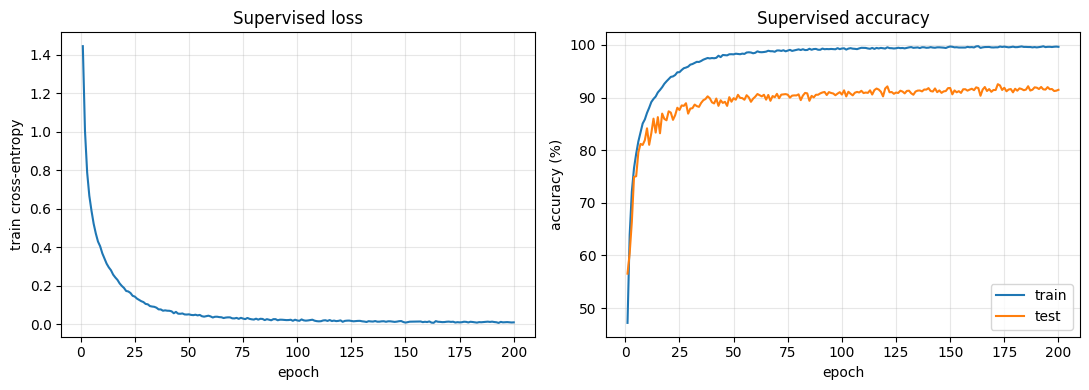

Saved figures/supervised_baseline_curves.png


In [6]:
# --- Cell 6: Learning-curve plots ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log['epoch'], log['train_loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train cross-entropy')
axes[0].set_title('Supervised loss'); axes[0].grid(alpha=0.3)

axes[1].plot(log['epoch'], [a*100 for a in log['train_acc']], label='train')
axes[1].plot(log['epoch'], [a*100 for a in log['test_acc']],  label='test')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy (%)')
axes[1].set_title('Supervised accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig(cfg['fig_path'], dpi=150)
plt.show()
print('Saved', cfg['fig_path'])


In [7]:
# --- Cell 7: Comparison vs Phase 1 SimCLR linear probe ---
# Shows SL vs SSL side-by-side. This is the core of requirement #2.
probe_path = Path('results/simclr_baseline_linear_probe.json')
if probe_path.exists():
    ssl_probe = json.loads(probe_path.read_text())
    ssl_final = ssl_probe['final_test_acc']
    ssl_best  = ssl_probe['best_test_acc']
else:
    ssl_final = ssl_best = None

sl_final = log['test_acc'][-1]
sl_best  = max(log['test_acc'])

print('CIFAR-10 test accuracy')
print('----------------------')
print(f'SSL linear probe (Phase 1) : final = {ssl_final*100:.2f}%  best = {ssl_best*100:.2f}%' if ssl_final else 'SSL linear probe: not found')
print(f'Supervised    (Phase 2)    : final = {sl_final*100:.2f}%  best = {sl_best*100:.2f}%')


CIFAR-10 test accuracy
----------------------
SSL linear probe (Phase 1) : final = 86.34%  best = 86.70%
Supervised    (Phase 2)    : final = 91.47%  best = 92.54%
